# Manufacturing Imperfections in Poled Crystals

Real periodically-poled crystals never match the idealized domain pattern a simulation assumes.
This notebook is a tutorial for `photonpairlab`'s **manufacturing-imperfection** modeling: three
fabrication-error mechanisms you can layer onto any poling pattern, and see how they degrade the
joint spectral amplitude (JSA), heralding purity, and Hong-Ou-Mandel (HOM) interference of an SPDC
source.

It assumes you've already been through `demo.ipynb` — the setup here (KTP, 775 nm pump, 30 mm
crystal, degenerate 1550 nm type-II SPDC) is deliberately the same, so the "ideal" baselines below
match what that notebook already showed you.

By the end you will have:

1. Applied each of the three fabrication-error mechanisms individually and seen what it does to a
   crystal's poling pattern
2. Combined them into a single "as-fabricated" crystal and compared its JSA/JSI, heralding purity,
   and HOM dip against the ideal design
3. Done all of the above for **both** plain periodic poling and sub-coherence-length apodized
   (`subcoh`) poling — apodization was designed to fix one kind of imperfection (a plain grating's
   own side-lobes), and it's worth seeing directly whether it also helps against *fabrication*
   noise, or not
4. Quantified, with a parameter sweep, *why* the two statistical models for wall-position error
   give such different answers about how much fabrication noise actually matters

## The three mechanisms

All three come from Graffitti, Costa-Filho, Kolthammer & Brańczyk, *"Design considerations for
high-purity heralded single-photon sources,"* Quantum Sci. Technol. 2, 035001 (2017)
**[[1]](#ref1)** — the same paper whose Eq. 5 & 9 already power `photonpairlab`'s poling-generation
machinery — plus Helmfrid & Arvidsson's earlier, more detailed treatment of wall-position error
**[[2]](#ref2)**.

- **Wall-position error** (`PolingResult.add_wall_position_error`) — domain walls don't land
  exactly where designed. Two statistical models, because they give *very* different answers:
  - `method="independent"`: each wall is offset from its own ideal position by an independent
    Gaussian draw. Errors don't accumulate — Graffitti et al. found this model's effect on purity
    negligible even at large $\sigma$.
  - `method="cumulative"` (default): each domain's *width* (not position) is drawn independently,
    so wall positions are a running sum of those widths — a random walk. Positional error grows
    with domain index. Helmfrid & Arvidsson **[[2]](#ref2)** found this is the model that actually
    matters for real devices.
- **Missed domains** (`PolingResult.add_missed_domain_error`) — a Bernoulli-selected subset of
  domains fail to invert during poling (a poling-voltage failure).
- **Duty-cycle bias** (`PolingResult.add_duty_cycle_bias`) — a systematic (not random) over- or
  under-poling: one polarity of domain is consistently a bit wider than its neighbor.

All three are chainable, functional methods on the `PolingResult` a poling generator returns — none
of them mutate anything in place, so you can freely compare a perturbed result against the
untouched original. `Crystal.apply_poling(...)` writes a (possibly perturbed) `PolingResult` back
onto a crystal and recomputes its diagnostic field-buildup arrays, ready for `SPDC_Simulation`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from photonpairlab import (
    Crystal,
    HOMAnalyzer,
    MaterialFactory,
    PulsedLaser,
    SPDC_Plotter,
    SPDC_Simulation,
    SPDCGridConfig,
    SpectralAnalyzer,
)

warnings.filterwarnings("ignore")

## Setup

Same material, pump, and crystal length as `demo.ipynb`'s periodic-poling section.

In [2]:
material = MaterialFactory.create("ktp1")   # potassium titanyl phosphate
pump_wavelength = 775e-9                     # -> degenerate 1550 nm telecom photons
pulse_duration = 1.7e-12
crystal_length = 30e-3
laser = PulsedLaser(pump_wavelength, pulse_duration=pulse_duration)

grid = SPDCGridConfig(steps=100, dev_nm=2.5)       # for the "before/after" showcase plots
sweep_grid = SPDCGridConfig(steps=50, dev_nm=2.5)  # smaller/faster, for the parameter sweep later


def run_and_analyze(crystal, grid=grid):
    results = SPDC_Simulation(crystal, laser, grid=grid).run()
    _, purity, K = SpectralAnalyzer(results).schmidt_decomposition()
    return results, purity, K

## Part 1: Periodic (QPM) poling

We'll build the ideal periodic grating first, exactly as in `demo.ipynb`, and keep it untouched as
our baseline for everything below.

coherence length: 23.1184 um, domains: 1297


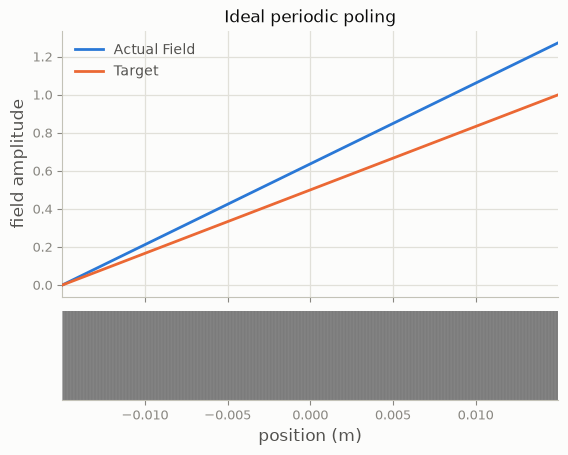

In [3]:
def build_periodic_crystal(coherence_length=None, resolution=5):
    crystal = Crystal(crystal_length=crystal_length, material=material,
                       pm_strategy="quasi", spdc_type="type-II", T=20.0,
                       coherence_length=coherence_length)
    poling = crystal.generate_poling(laser=laser, mode="periodic",
                                      wavelength_signal=1550e-9, wavelength_idler=1550e-9,
                                      resolution=resolution)
    return crystal, poling


crystal_ideal, poling_ideal = build_periodic_crystal()
Lc = crystal_ideal.coherence_length  # pin this for every crystal built below, so they all share
                                      # exactly the same nominal grating design
print(f"coherence length: {Lc*1e6:.4f} um, domains: {len(poling_ideal.domain_signs)}")


fig, (field_ax, pattern_ax) = SPDC_Plotter.plot_poling_profile(crystal_ideal)
field_ax.set_title("Ideal periodic poling")
plt.show()

### Mechanism 1: wall-position error

Both models below use the *same* $\sigma=0.08$ (as a fraction of the nominal domain width) — the
upper end of what Graffitti et al. tested. Watch what happens to the "actual field" curve (top) in
each case — at ~1300 domains across the full crystal, the bar-code strip (bottom) is too fine to
show individual domain shifts either way, but it's still useful as a texture check (e.g. it would
immediately reveal a gross error like an accidentally-truncated pattern).

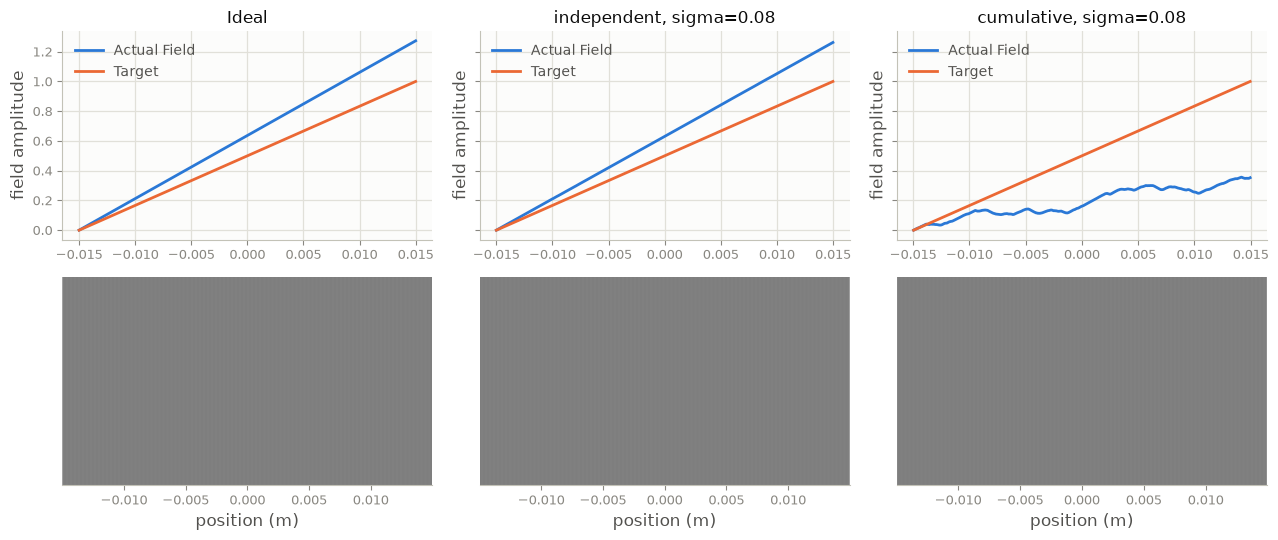

In [4]:
crystal_demo, _ = build_periodic_crystal(coherence_length=Lc)

fig, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharey="row")

crystal_demo.apply_poling(poling_ideal)
SPDC_Plotter.plot_poling_profile(crystal_demo, fig=fig, ax=(axes[0, 0], axes[1, 0]))
axes[0, 0].set_title("Ideal")

rng = np.random.default_rng(0)
perturbed_independent = poling_ideal.add_wall_position_error(method="independent", sigma=0.08, rng=rng)
crystal_demo.apply_poling(perturbed_independent)
SPDC_Plotter.plot_poling_profile(crystal_demo, fig=fig, ax=(axes[0, 1], axes[1, 1]))
axes[0, 1].set_title("independent, sigma=0.08")

rng = np.random.default_rng(0)
perturbed_cumulative = poling_ideal.add_wall_position_error(method="cumulative", sigma=0.08, rng=rng)
crystal_demo.apply_poling(perturbed_cumulative)
SPDC_Plotter.plot_poling_profile(crystal_demo, fig=fig, ax=(axes[0, 2], axes[1, 2]))
axes[0, 2].set_title("cumulative, sigma=0.08")

plt.tight_layout()
plt.show()

`independent` still tracks the ideal linear buildup closely — a bounded wobble around the nominal
grid, since each wall is anchored back to its own ideal position. `cumulative`, at the *same*
nominal $\sigma$, visibly drifts and can bend the whole curve away from the target: because domain
*widths* (not positions) are the i.i.d. random variable, positional error is a random walk that
compounds with every additional domain. We'll make this quantitative in the sweep near the end of
this section.

### Mechanism 2: missed domains

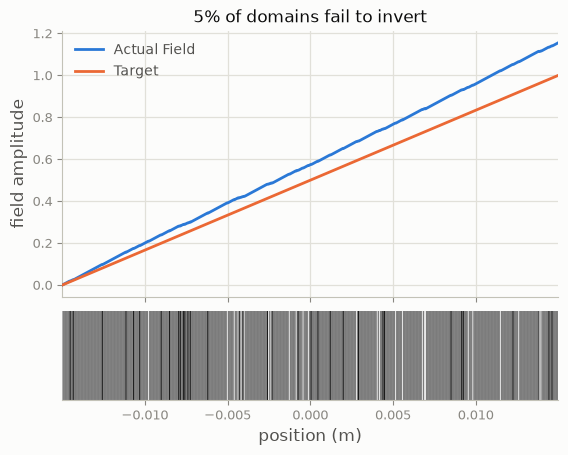

In [5]:
crystal_demo, _ = build_periodic_crystal(coherence_length=Lc)
rng = np.random.default_rng(3)
perturbed_missed = poling_ideal.add_missed_domain_error(probability=0.05, rng=rng)
crystal_demo.apply_poling(perturbed_missed)

fig, (field_ax, pattern_ax) = SPDC_Plotter.plot_poling_profile(crystal_demo)
field_ax.set_title("5% of domains fail to invert")
plt.show()

A missed domain doesn't invert at all, so it just keeps the previous domain's sign, occasionally
merging two neighboring domains into one double-width block. Unlike wall-position error, this
doesn't touch domain *widths* at all, so the grid stays perfectly uniform; only the sign sequence
changes — and unlike duty-cycle bias below, it's not quadratically protected near any particular
value, so even a modest missed-domain rate visibly tilts the field-buildup curve.

### Mechanism 3: duty-cycle bias

A non-random systematic bias, where every `+1` domain is grown and every `-1` domain shrunk by the same
fraction (or vice-versa for a negative factor). As a result, we can model a consistent fabrication asymmetry rather
than domain-by-domain noise.

By using a large `factor=0.6`, the effect is visible in the plot below. The Fourier fundamental
of a square wave is *maximized* exactly at a 50% duty cycle, so the field-buildup amplitude is only
*quadratically* sensitive to a small duty-cycle bias near 50%, not linearly. A realistic few-percent
bias barely moves it at all. Try `factor=0.05` below and compare.

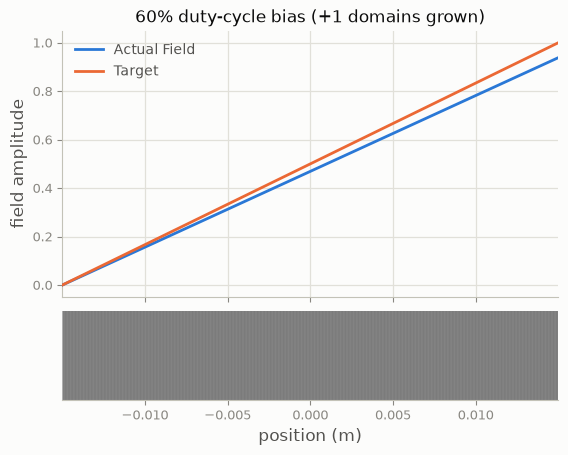

In [6]:
crystal_demo, _ = build_periodic_crystal(coherence_length=Lc)
perturbed_duty = poling_ideal.add_duty_cycle_bias(factor=0.6)
crystal_demo.apply_poling(perturbed_duty)

fig, (field_ax, pattern_ax) = SPDC_Plotter.plot_poling_profile(crystal_demo)
field_ax.set_title("60% duty-cycle bias (+1 domains grown)")
plt.show()

### Putting it together: a realistic "as-fabricated" crystal

Chaining all three error sources at once with values from literature:
$\sigma=0.02$ (cumulative model — the KTP duty-cycle-error measurement in Mann et al.
**[[3]](#ref3)** found random errors around 2% of domain length), a 1% missed-domain rate, and a 5%
duty-cycle bias.

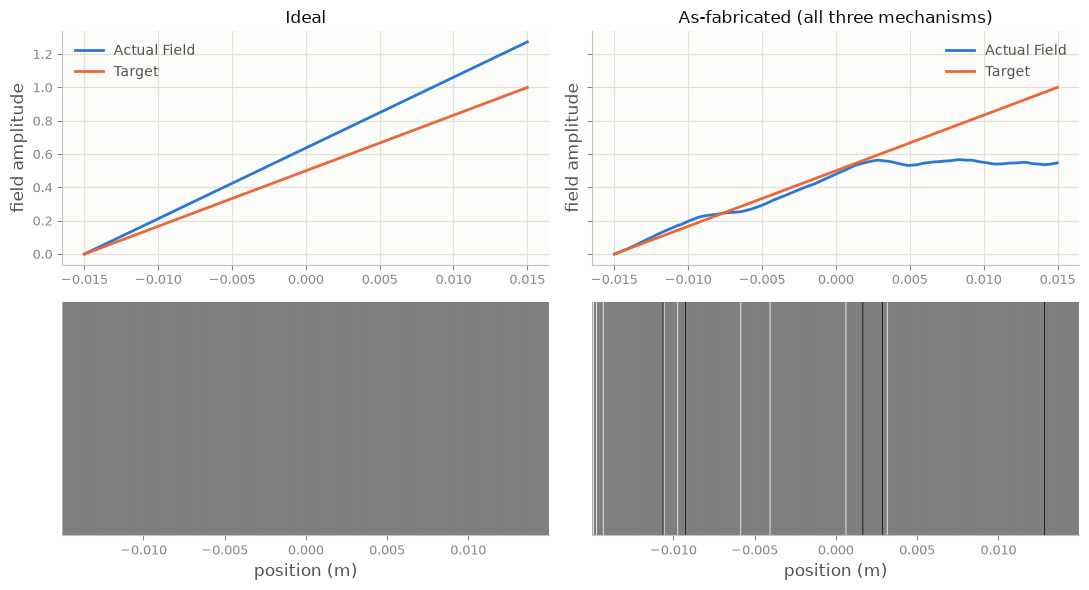

In [7]:
crystal_perturbed, _ = build_periodic_crystal(coherence_length=Lc)
rng = np.random.default_rng(1)
poling_perturbed = (
    poling_ideal
    .add_wall_position_error(method="cumulative", sigma=0.02, rng=rng)
    .add_missed_domain_error(probability=0.01, rng=rng)
    .add_duty_cycle_bias(factor=0.05)
)
crystal_perturbed.apply_poling(poling_perturbed)

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey="row")
SPDC_Plotter.plot_poling_profile(crystal_ideal, fig=fig, ax=(axes[0, 0], axes[1, 0]))
axes[0, 0].set_title("Ideal")
SPDC_Plotter.plot_poling_profile(crystal_perturbed, fig=fig, ax=(axes[0, 1], axes[1, 1]))
axes[0, 1].set_title("As-fabricated (all three mechanisms)")
plt.tight_layout()
plt.show()

### Effect on the JSA/JSI

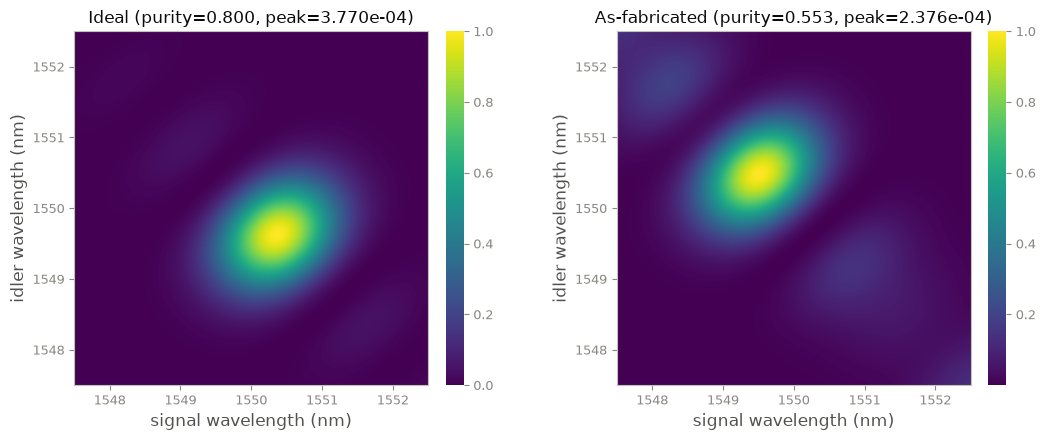

peak JSI ratio (as-fabricated / ideal): 0.630
purity: 0.800 -> 0.553   (K = 1/purity: 1.251 -> 1.807)


In [8]:
results_ideal, purity_ideal, K_ideal = run_and_analyze(crystal_ideal)
results_perturbed, purity_perturbed, K_perturbed = run_and_analyze(crystal_perturbed)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
SPDC_Plotter(results_ideal).plot_result(key="JSI", fig=fig, ax=axes[0])
axes[0].set_title(f"Ideal (purity={purity_ideal:.3f}, peak={results_ideal.JSI.max():.3e})")
SPDC_Plotter(results_perturbed).plot_result(key="JSI", fig=fig, ax=axes[1])
axes[1].set_title(f"As-fabricated (purity={purity_perturbed:.3f}, peak={results_perturbed.JSI.max():.3e})")
plt.tight_layout()
plt.show()

print(f"peak JSI ratio (as-fabricated / ideal): {results_perturbed.JSI.max() / results_ideal.JSI.max():.3f}")
print(f"purity: {purity_ideal:.3f} -> {purity_perturbed:.3f}   (K = 1/purity: {K_ideal:.3f} -> {K_perturbed:.3f})")

Both the peak brightness and the heralding purity drop — the JSA broadens and picks up asymmetric
structure the ideal design doesn't have, exactly the qualitative effect Graffitti et al. report
(peak amplitude is the more consistently affected quantity; purity's sensitivity depends heavily on
*which* wall-position model dominates, as we'll see in the sweep below).

### Effect on Hong-Ou-Mandel interference

Following the same comparison `demo.ipynb` used: interfere each source's heralded signal photon
with an independently-generated photon from an identical copy of itself.

           ideal: minimum coincidence probability = 0.1002
   as-fabricated: minimum coincidence probability = 0.2234


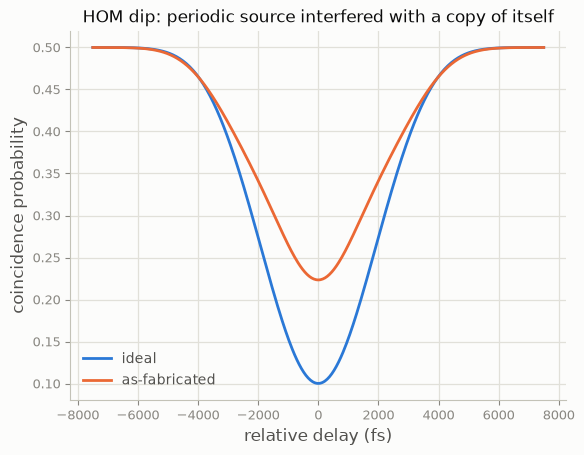

In [9]:
taus_s = np.linspace(-7500e-15, 7500e-15, 401)

hom_results = {}
for label, results in [("ideal", results_ideal), ("as-fabricated", results_perturbed)]:
    hom = HOMAnalyzer(results, results)
    hom_results[label] = hom.compute_two_mode_HOM(mode1="signal", mode2="signal", taus_s=taus_s)
    print(f"{label:>16s}: minimum coincidence probability = {hom_results[label].coincidence_probabilities.min():.4f}")

fig, ax = SPDC_Plotter.plot_hom_dip(hom_results)
ax.set_title("HOM dip: periodic source interfered with a copy of itself")
plt.show()

A shallower, broader dip for the as-fabricated source: its heralded photons are less spectrally
pure (matching the purity numbers above), so two independently-heralded photons from it are more
distinguishable, and the two-photon interference is less than perfect even though both photons come
from *the same* (imperfect) design.

### How much does $\sigma$ matter? A quantitative sweep

The demo above used one random draw at one $\sigma$. Let's sweep $\sigma$ for both wall-position
models and see the divergence directly — averaging a few random seeds per point, since a single
draw of the cumulative (random-walk) model is noisy.

In [10]:
def sweep_wall_position_error(poling_ideal, crystal_builder, sigmas, methods, n_seeds=4, base_seed=100):
    crystal_scratch, _ = crystal_builder()
    rows = []
    for method in methods:
        for sigma in sigmas:
            purities, peaks = [], []
            for k in range(n_seeds):
                rng = np.random.default_rng(base_seed + k)
                perturbed = poling_ideal.add_wall_position_error(method=method, sigma=sigma, rng=rng)
                crystal_scratch.apply_poling(perturbed)
                results, purity, _ = run_and_analyze(crystal_scratch, grid=sweep_grid)
                purities.append(purity)
                peaks.append(results.JSI.max())
            rows.append({
                "method": method, "sigma": sigma,
                "purity_mean": np.mean(purities), "purity_std": np.std(purities),
                "peak_mean": np.mean(peaks), "peak_std": np.std(peaks),
            })
    return rows


sigmas = [0.0, 0.01, 0.02, 0.04, 0.06, 0.08]
sweep_periodic = sweep_wall_position_error(
    poling_ideal, lambda: build_periodic_crystal(coherence_length=Lc), sigmas,
    methods=["independent", "cumulative"],
)

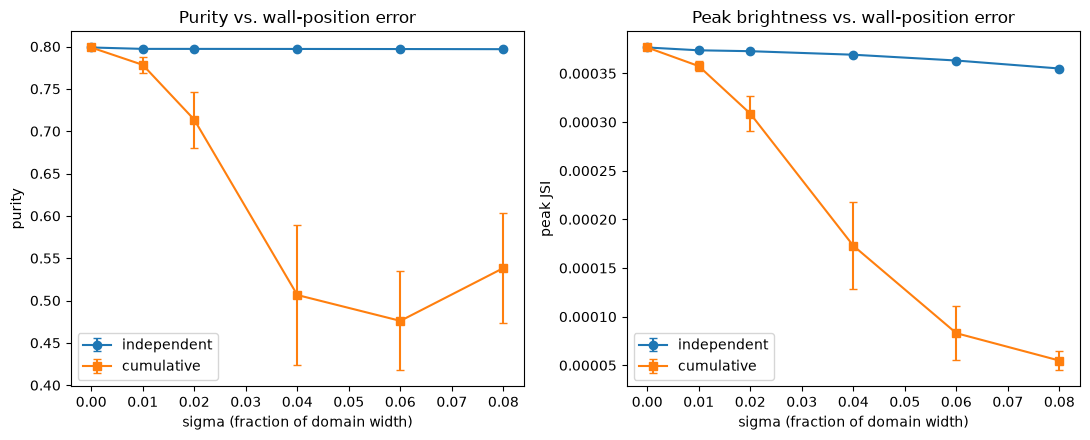

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for method, marker in [("independent", "o"), ("cumulative", "s")]:
    rows = [r for r in sweep_periodic if r["method"] == method]
    s = [r["sigma"] for r in rows]
    axes[0].errorbar(s, [r["purity_mean"] for r in rows], yerr=[r["purity_std"] for r in rows],
                      marker=marker, label=method, capsize=3)
    axes[1].errorbar(s, [r["peak_mean"] for r in rows], yerr=[r["peak_std"] for r in rows],
                      marker=marker, label=method, capsize=3)
axes[0].set_xlabel("sigma (fraction of domain width)")
axes[0].set_ylabel("purity")
axes[0].set_title("Purity vs. wall-position error")
axes[0].legend()
axes[1].set_xlabel("sigma (fraction of domain width)")
axes[1].set_ylabel("peak JSI")
axes[1].set_title("Peak brightness vs. wall-position error")
axes[1].legend()
plt.tight_layout()
plt.show()

This is Helmfrid & Arvidsson's finding, reproduced directly: the `independent` (bounded) model
barely moves purity even out to $\sigma=0.08$ — matching Graffitti et al.'s own conclusion that
random-but-bounded wall error is close to harmless. The `cumulative` (random-walk) model, at the
*exact same* nominal $\sigma$, degrades purity sharply, because with ~1300 domains in this crystal
even a small per-domain width fluctuation accumulates into a large positional drift by the far end
of the crystal. **Which model is realistic depends on your poling process** — if positional noise
comes from many small independent per-domain effects (voltage jitter, domain-switching time
variation), the accumulating `cumulative` model is the physically appropriate one; if it's closer to
a fixed per-wall placement tolerance, `independent` is more appropriate. When in doubt, the
`cumulative` model is the conservative (worse-case) choice.

## Part 2: Sub-coherence-length apodized (`subcoh`) poling

Apodization exists to fix a *different* problem: a plain periodic grating's own square-wave
side-lobes, which limit purity even with a perfectly-fabricated crystal (see `demo.ipynb`). It's
worth checking directly whether that same careful domain-by-domain design also happens to help
against *fabrication* noise, or whether it's simply a different (and possibly more delicate)
structure to perturb.

coherence length: 23.1184 um, domains: 15000


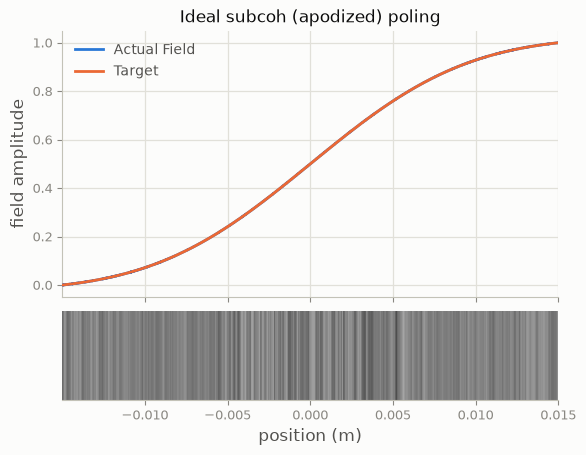

In [12]:
def build_subcoh_crystal(coherence_length=None, w=2e-6):
    crystal = Crystal(crystal_length=crystal_length, material=material,
                       pm_strategy="quasi", spdc_type="type-II", T=20.0,
                       coherence_length=coherence_length, w=w)
    poling = crystal.generate_poling(laser=laser, mode="subcoh",
                                      wavelength_signal=1550e-9, wavelength_idler=1550e-9)
    return crystal, poling


crystal_ideal_s, poling_ideal_s = build_subcoh_crystal()
Lc_s = crystal_ideal_s.coherence_length
print(f"coherence length: {Lc_s*1e6:.4f} um, domains: {len(poling_ideal_s.domain_signs)}")

fig, (field_ax, pattern_ax) = SPDC_Plotter.plot_poling_profile(crystal_ideal_s)
field_ax.set_title("Ideal subcoh (apodized) poling")
plt.show()

Notice `add_wall_position_error`/`add_missed_domain_error`/`add_duty_cycle_bias` are exactly the
same calls as for periodic poling — they work on *any* poling result that carries the
`domain_signs`/`domain_widths` metadata, regardless of which algorithm produced it. `subcoh`'s
domains aren't a strict alternating $+1,-1,+1,-1,\dots$ sequence (the apodization algorithm chooses
each domain's sign to track a target envelope, so runs of the same sign do occur), but none of the
three mechanisms care about that — missed-domain flips and duty-cycle bias key off each domain's
*own* current sign, and wall-position error doesn't look at sign at all.

### Applying the same combined imperfections

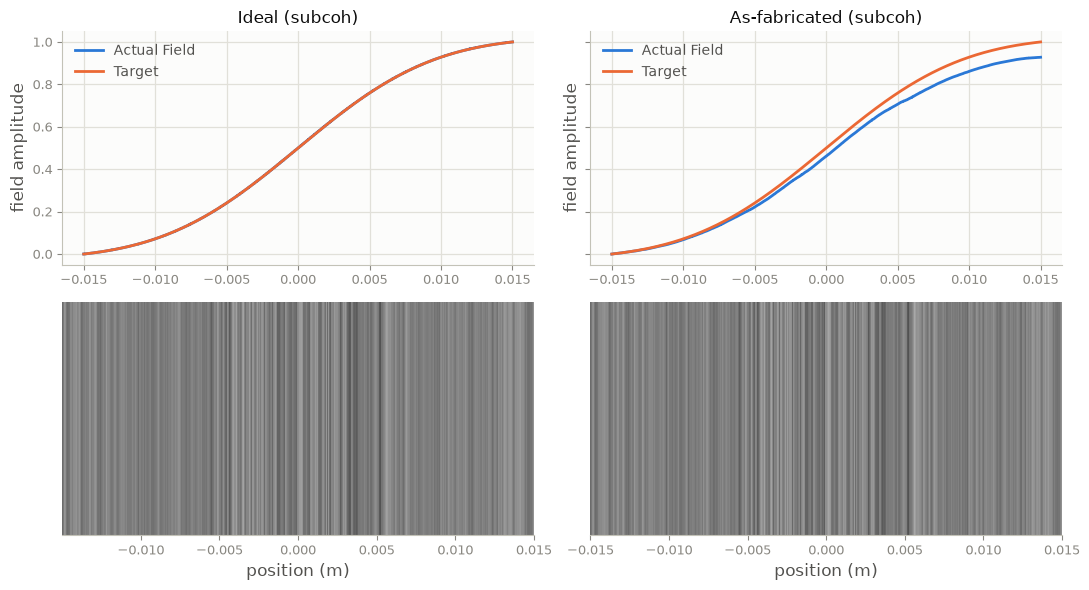

In [13]:
crystal_perturbed_s, _ = build_subcoh_crystal(coherence_length=Lc_s)
rng = np.random.default_rng(15)
poling_perturbed_s = (
    poling_ideal_s
    .add_wall_position_error(method="cumulative", sigma=0.02, rng=rng)
    .add_missed_domain_error(probability=0.01, rng=rng)
    .add_duty_cycle_bias(factor=0.05)
)
crystal_perturbed_s.apply_poling(poling_perturbed_s)

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey="row")
SPDC_Plotter.plot_poling_profile(crystal_ideal_s, fig=fig, ax=(axes[0, 0], axes[1, 0]))
axes[0, 0].set_title("Ideal (subcoh)")
SPDC_Plotter.plot_poling_profile(crystal_perturbed_s, fig=fig, ax=(axes[0, 1], axes[1, 1]))
axes[0, 1].set_title("As-fabricated (subcoh)")
plt.tight_layout()
plt.show()

### Effect on the JSA/JSI

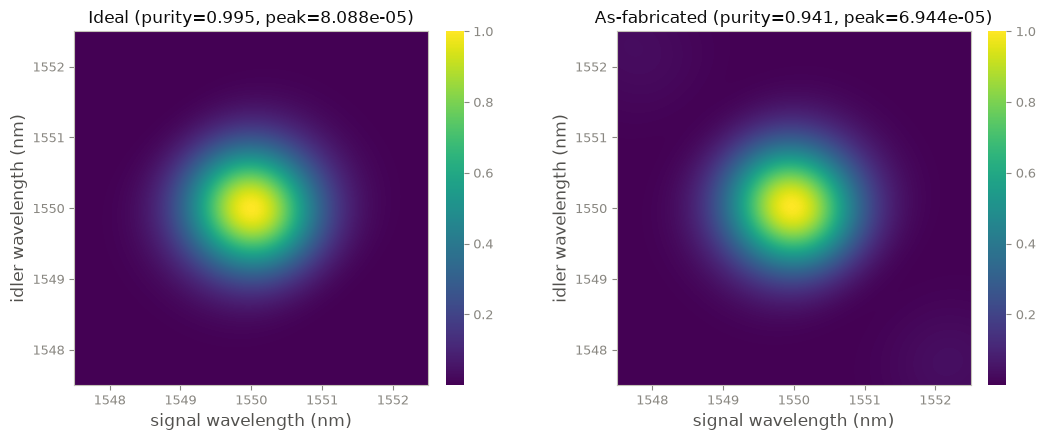

peak JSI ratio (as-fabricated / ideal): 0.858
purity: 0.995 -> 0.941   (K = 1/purity: 1.005 -> 1.063)


In [14]:
results_ideal_s, purity_ideal_s, K_ideal_s = run_and_analyze(crystal_ideal_s)
results_perturbed_s, purity_perturbed_s, K_perturbed_s = run_and_analyze(crystal_perturbed_s)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
SPDC_Plotter(results_ideal_s).plot_result(key="JSI", fig=fig, ax=axes[0])
axes[0].set_title(f"Ideal (purity={purity_ideal_s:.3f}, peak={results_ideal_s.JSI.max():.3e})")
SPDC_Plotter(results_perturbed_s).plot_result(key="JSI", fig=fig, ax=axes[1])
axes[1].set_title(f"As-fabricated (purity={purity_perturbed_s:.3f}, peak={results_perturbed_s.JSI.max():.3e})")
plt.tight_layout()
plt.show()

print(f"peak JSI ratio (as-fabricated / ideal): {results_perturbed_s.JSI.max() / results_ideal_s.JSI.max():.3f}")
print(f"purity: {purity_ideal_s:.3f} -> {purity_perturbed_s:.3f}   (K = 1/purity: {K_ideal_s:.3f} -> {K_perturbed_s:.3f})")

Apodization's near-unity ideal purity gives it a lot more room to fall before it's in the same
territory as the periodic source above — but at the same fabrication-error magnitudes, it *does*
still fall substantially. Apodization buys you a better starting point, not immunity to fabrication
noise.

### Effect on HOM interference

          ideal (subcoh): minimum coincidence probability = 0.0024
  as-fabricated (subcoh): minimum coincidence probability = 0.0296


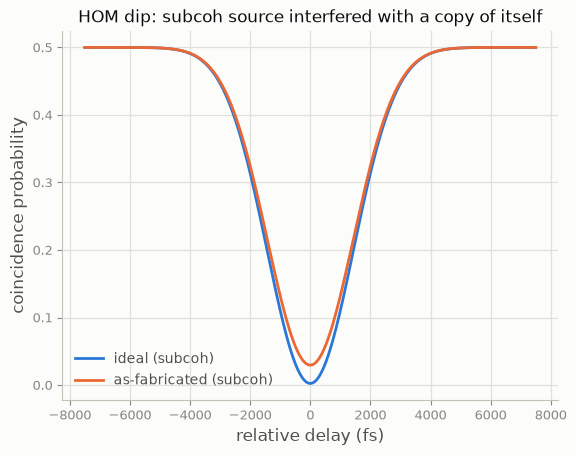

In [15]:
hom_results_s = {}
for label, results in [("ideal (subcoh)", results_ideal_s), ("as-fabricated (subcoh)", results_perturbed_s)]:
    hom = HOMAnalyzer(results, results)
    hom_results_s[label] = hom.compute_two_mode_HOM(mode1="signal", mode2="signal", taus_s=taus_s)
    print(f"{label:>24s}: minimum coincidence probability = {hom_results_s[label].coincidence_probabilities.min():.4f}")

fig, ax = SPDC_Plotter.plot_hom_dip(hom_results_s)
ax.set_title("HOM dip: subcoh source interfered with a copy of itself")
plt.show()

### Is `subcoh` more or less *sensitive* to wall-position error than periodic poling?

The ideal-purity comparison above (0.99 vs. 0.76) isn't quite the same question as *sensitivity* —
how fast purity degrades as $\sigma$ grows. Let's sweep the `cumulative` model (the one that
actually matters, per Part 1) for both poling modes and compare directly, reusing the periodic curve
already computed above.

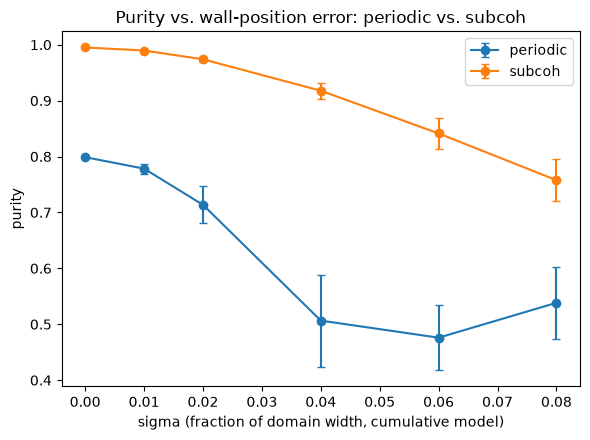

In [16]:
sweep_subcoh = sweep_wall_position_error(
    poling_ideal_s, lambda: build_subcoh_crystal(coherence_length=Lc_s), sigmas,
    methods=["cumulative"],
)

fig, ax = plt.subplots(figsize=(6, 4.5))
for label, rows in [
    ("periodic", [r for r in sweep_periodic if r["method"] == "cumulative"]),
    ("subcoh", sweep_subcoh),
]:
    s = [r["sigma"] for r in rows]
    ax.errorbar(s, [r["purity_mean"] for r in rows], yerr=[r["purity_std"] for r in rows],
                marker="o", label=label, capsize=3)
ax.set_xlabel("sigma (fraction of domain width, cumulative model)")
ax.set_ylabel("purity")
ax.set_title("Purity vs. wall-position error: periodic vs. subcoh")
ax.legend()
plt.tight_layout()
plt.show()

`subcoh` starts from a much better place and stays somewhat ahead of `periodic` across the sweep,
but both curves fall with a similar shape and roughly converge at large $\sigma$ — apodization
doesn't fundamentally change *how* sensitive the source is to accumulating wall-position error, it
just gives you more purity budget to spend before it becomes a problem.

## Where to go from here

- `src/photonpairlab/crystal/phasematching/imperfections.py` has the underlying pure array
  functions (`perturb_widths_cumulative`, `perturb_widths_independent`, `apply_missed_domains`,
  `apply_duty_cycle_bias`, `resample_domains_to_fine_grid`) if you want to build a custom
  perturbation pipeline instead of chaining the three `PolingResult` methods.
- `PolingResult.add_wall_position_error`/`.add_missed_domain_error`/`.add_duty_cycle_bias`
  docstrings in `src/photonpairlab/crystal/phasematching/pm_result.py` document every parameter.
- `tests/tests_crystal/test_imperfections.py` has focused regression tests, including one that
  builds a `PolingResult` entirely by hand (no `Crystal`/strategy involved) to demonstrate that any
  poling algorithm — not just `periodic`/`constant`/`subcoh` — gets imperfection support for free
  simply by populating `domain_signs`/`domain_widths`/`resolution` on the `PolingResult` it returns.

## References

1. <a id="ref1"></a>F. Graffitti, D. Kundys, D. T. Reid, A. M. Brańczyk, A. Fedrizzi, "Pure down-conversion photons
   through sub-coherence-length domain engineering," *Quantum Science and Technology* **2**, 035001
   (2017). [arXiv:1704.03683](https://arxiv.org/abs/1704.03683) — Sec. III.3.2 models exactly the
   three fabrication-error mechanisms used in this notebook.

2. <a id="ref2"></a>S. Helmfrid, G. Arvidsson, "Influence of randomly varying domain lengths and nonuniform
   effective index on second-harmonic generation in quasi-phase-matching waveguides," *Journal of
   the Optical Society of America B* **8**, 797 (1991). No preprint is available (predates arXiv's
   coverage of optics) — the foundational comparison of the independent-wall-position vs.
   independent-domain-length (cumulative) error models used in `add_wall_position_error`.

3. <a id="ref3"></a>F. Mann, H. M. Chrzanowski, S. Ramelow, "Low random duty-cycle errors in periodically-poled
   KTP revealed by sum-frequency generation," *Optics Letters* **46**, 3049 (2021).
   [arXiv:2104.04464](https://arxiv.org/abs/2104.04464) — the ~2% figure used for the
   "as-fabricated" $\sigma$ in this notebook.